# Prueba de progreso 2
### 1. Carga de datos
Los datos se cargan como CSV. En contreto los referentes a la semana del 27 de enero de 2025 "20250127". Los archivos fuente serán referenciados como "20250127_datosvolumen.csv", "20250127_datosvelocidad.csv" y "estaciones.csv"
La libreria pandas permite cargar los csv separando atributos por ";"

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

vol = pd.read_csv("20250127_datosvolumen.csv", sep=";", encoding="latin-1")
vel = pd.read_csv("20250127_datosvelocidad.csv", sep=";", encoding="latin-1")
est = pd.read_csv("estaciones.csv", sep=";", encoding="latin-1")

Nota: Debido a que el conjunto de datos utiliza codificación de caracteres "Latin-1" en vez "UTF-8" es necesario indicarlo al leer el CSV

## 2. Analisis exploratorio
Despues de revisar los campos se ha encontrado que los campos de hora la representan mediante rangos de media hora (velocidad) y que algunos campos presentan espacios en blanco que dificulta trabajar con los datos (velocidad , volumen y estaciones). Ademas como se comenta en el enunciado hay disparidad entre los campos fecha y hora de volumen y velocidad, además de referenciar la estación de forma distinta (ETD en velocidad y estación en volumen). Algunos campos como velocidad media utilizan la coma en vez del punto para los decimales

## 3. Preprocesamiento
- Para facilitar el trabajar con los datos se ha optado por reducir la dimensionalidad de los datos de volumen debido a que una sola columna para pesados, otra para ligeros y otra midiendo el volumen total es suficiente.
- Después añadir las columnas corespondientes se han eliminado las columnas originales para evitar redundancia.
- También se ha eliminado una columna 13 sin nombre en velocidad que no contiene datos:

In [ ]:
# Busqueda dinamica de columnas de ligeros y pesados
ligeros = [c for c in vol.columns if "ligeros" in c]
pesados = [c for c in vol.columns if "pesados" in c]

# Añadir columnas de totales
vol["Total_vehiculos"] = vol[ligeros + pesados].sum(axis=1)
vol["Total_ligeros"] = vol[ligeros].sum(axis=1)
vol["Total_pesados"] = vol[pesados].sum(axis=1)

# Eliminar columnas originales
vol = vol.drop(columns=ligeros + pesados)



- Se han eliminado errores con los datos como los encontrados en la columna "Hora" de velocidad y volumen. Los valores llegaban por encima de las 24 horas. Se ha restado una hora a todas las horas de los 2 datasets debido a que todas las horas empezaban en 01:00 y terminaban en 24:00.
- Se ha utilizado el primer valor del rango horario en velocidad.

In [ ]:
# Eliminar el segundo valor del rango Horario
vel["Hora"] = vel["Hora"].str.split(" - ").str[0]


# Modificar la columna "Hora" restando 1 hora 
vel["h"] = vel["Hora"].str.split(":").str[0].astype(int) - 1
vel["m"] = vel["Hora"].str.split(":").str[1]
vel["s"] = vel["Hora"].str.split(":").str[2]

# Modificar la columna "Hora" restando 1 hora para cuadrar el formato de Hora
vol["h"] = vol["Hora"].str.split(":").str[0].astype(int) - 1
vol["m"] = vol["Hora"].str.split(":").str[1]

# Reescribir la columna "Hora" con el nuevo formato
vol["Hora"] = vol["h"].astype(str).str.zfill(2) + ":" + vol["m"]
vel["Hora"] = vel["h"].astype(str).str.zfill(2) + ":" + vel["m"].astype(str).str.zfill(2) + ":" + vel["s"]

# Eliminar columnas auxiliares
vol = vol.drop(columns=["h", "m"])
vel = vel.drop(columns=["h", "m", "s"])

- Se han unido los valores de Fecha y hora en formato datetime para poder trabajarlos sin errores y con el mismo formato

In [ ]:
# Convertir la fecha a formato datetime con la Hora suprimiendo los espacios en blanco de la columna Fecha

vol["Fecha"] = vol["Fecha"].astype(str).str.strip()
vol["Hora"] = vol["Hora"].astype(str).str.strip()

vol["Fecha"] = pd.to_datetime(vol["Fecha"] + " " + vol["Hora"], format="%d/%m/%Y %H:%M")
vel["Fecha"] = pd.to_datetime(vel["Fecha"] + " " + vel["Hora"], format="%Y-%m-%d %H:%M:%S")

vol = vol.drop(columns=["Hora"])
vel = vel.drop(columns=["Hora"])

- Se ha reemplazado Sistema en velocidad por el código ETD encontrado en la descripción para que no haya discrepancia con el mismo campo en volumen.

In [ ]:
# Reemplazar sistema por código ETD en velocidad y que cuadre con volumen
vel["Estacion"] = vel["ETD"].str.extract(r"\]\s*(\d+)-ETD")

vol["Estacion"] = pd.to_numeric(vol["Estacion"], errors="coerce")
vel["Estacion"] = pd.to_numeric(vel["Estacion"], errors="coerce")

## 4. Elección de Algoritmo
Se selecciona K-Means como algoritmo de clustering debido a su eficiencia en conjuntos de datos numéricos de tamaño medio, su capacidad para identificar patrones globales y la interpretabilidad de sus centroides, lo cual resulta especialmente útil para caracterizar perfiles horarios de tráfico.
### 4.1. Selección de variables
Para el análisis de clustering se seleccionaron variables representativas del comportamiento del tráfico en: intensidad, composición de vehiculo y distrivución espacial y temporal. Estas variables permiten caracterizar patrones de circulación diferenciados por hora y tipo de vía.
Específicamente las variables son:
- Total_vehiculos
- Total_ligeros
- Total_pesados
- Velocidad media (km/h)
- Hora_num
- X
- Y

In [ ]:
# Unir los dataframes de volumen y velocidad
df = vol.merge(
    vel,
    on=["Fecha", "Estacion"],
    how="inner"
)

df = df.merge(
    est,
    left_on="Estacion",
    right_on="ETD code",
    how="left"
)

# Crear una nueva columna "Hora_num" con la hora en formato numérico a partir de la columna "Fecha"

df["Hora_num"] = pd.to_datetime(df["Fecha"], errors="coerce").dt.hour

features = [
    "Total_vehiculos",
    "Total_ligeros",
    "Total_pesados",
    "Velocidad media (km/h)",
    "Hora_num"
]

# Limpiar y convertir las columnas numéricas a formato numérico, reemplazando los valores vacíos por NaN
for c in ["Total_vehiculos", "Total_ligeros", "Total_pesados", "Velocidad media (km/h)"]:
    df[c] = (
        df[c]
        .astype(str)
        .str.strip()
        .replace("", pd.NA)
        .replace(" ", pd.NA)
        .str.replace(",", ".", regex=False)
    )
    df[c] = pd.to_numeric(df[c], errors="coerce")

X = df[features].dropna()

# Escalar las características para KMeans
X_scaled = StandardScaler().fit_transform(X)

## 5. Interpretación de resultados
### 5.1. Método del codo
Para determinar el número adecuado de clusters se utilizó el método del codo , que consiste en analizar la evolución de la inercia del modelo K-Means al variar el número de grupos. La inercia mide la suma de distancias cuadradas de cada observación al centroide de su cluster, por lo que valores menores indican una mejor compactación interna de los grupos.

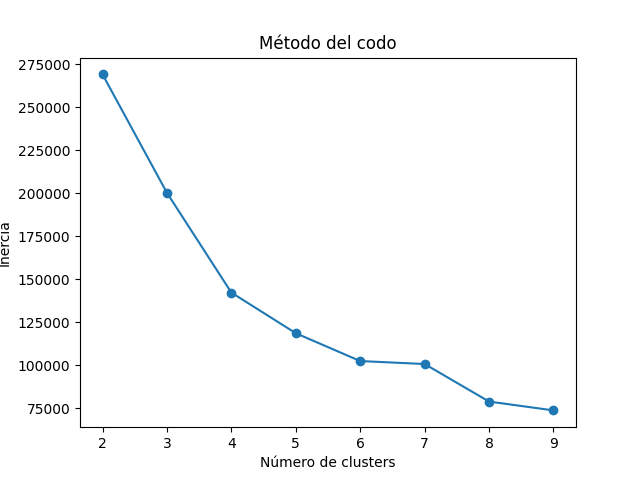

Como se observa en la figura, la inercia disminuye significativamente al aumentar el número de clusters hasta k = 4. A partir de ese punto, la reducción de la inercia es más gradual hasta que se reduce completamente a partir de k=6, lo que indica que añadir más clusters no aporta mejoras sustanciales en la estructura del modelo.

Por este motivo, se seleccionó k = 4 como número óptimo de clusters, al representar un equilibrio adecuado entre simplicidad del modelo y capacidad de representación de los patrones de tráfico

In [ ]:
# Método del codo para determinar el número óptimo de clusters
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 10), inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

# Aplicar KMeans con el número óptimo de clusters 
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

df.groupby("cluster")[features].mean()

### 5.2. PCA
Con el objetivo de analizar visualmente la estructura de los clusters obtenidos, se aplicó un análisis de componentes principales para reducir la dimensionalidad del conjunto de variables seleccionadas. Esta técnica permite proyectar los datos originales en un espacio bidimensional conservando la mayor parte posible de la variabilidad presente en los datos.
La reducción a dos dimensiones facilita la representación gráfica de las observaciones y permite evaluar la separación entre los clusters generados por el algoritmo K-Means, así como detectar posibles solapamientos entre grupos.

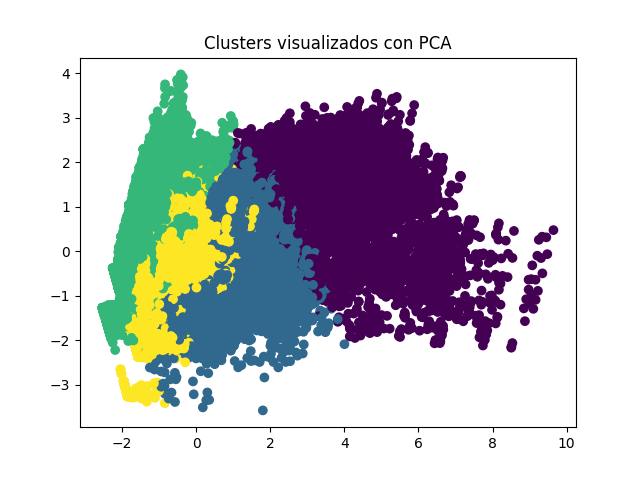

La representación obtenida mediante PCA muestra una separación clara de uno de los clusters respecto al resto, lo que indica la existencia de un perfil de tráfico diferenciado dentro del conjunto de datos. Por otro lado, algunos clusters presentan cierto solapamiento parcial.

In [ ]:
# PCA para visualizar los clusters


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["cluster"])
plt.title("Clusters visualizados con PCA")
plt.show()

## 6. Github
[Repositorio](https://github.com/errepeje/Gipuzkoa_traffic)